In [2]:
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive.zip


In [3]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import zipfile
import os

# Unzip the uploaded archive if it exists
if os.path.exists('archive.zip'):
    with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
        zip_ref.extractall('.')

train = pd.read_csv(
    "Genre Classification Dataset/train_data.txt",
    sep=" ::: ",
    engine="python",
    names=["ID","Genre","Description"]
)

train.head()

,ID,Genre,Description
1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [8]:
print("Shape:", train.shape)

print("\nGenres:")
print(train["Genre"].value_counts())

train.sample(5)

Shape: (54214, 3)

Genres:
Genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
mystery          319
musical          277
biography        265
history          243
game-show        194
news             181
war              132
Name: count, dtype: int64


,ID,Genre,Description
5662,I Love My Bicycle: The Story of FBM Bikes (2009),documentary,In reaction to the big business run companies ...
51687,Shadows and Fog (1991),comedy,"A small and insignificant bookkeeper, Kleinman..."
23346,Maria Chapdelaine (1983),drama,"A young woman, living with her parents and sib..."
12396,Rachel Is (2009),documentary,"In her feature directorial debut, Charlotte Gl..."
50974,Mam'zelle Bonaparte (1942),drama,Cora Pearl is the mistress of Napoleon the Thi...


In [9]:
X_train = train["Description"]
y_train = train["Genre"]

In [10]:
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            max_features=50000,
            ngram_range=(1,2)
        )
    ),
    (
        "classifier",
        LinearSVC()
    )
])

In [11]:
model.fit(X_train, y_train)

print("Training Completed")

Training Completed


In [13]:
test = pd.read_csv(
    "Genre Classification Dataset/test_data.txt",
    sep=" ::: ",
    engine="python",
    names=["ID","Description"]
)

test.head()

,ID,Description
1,Edgar's Lunch (1998),"L.R. Brane loves his life - his car, his apart..."
2,La guerra de papá (1977),"Spain, March 1964: Quico is a very naughty chi..."
3,Off the Beaten Track (2010),One year in the life of Albin and his family o...
4,Meu Amigo Hindu (2015),"His father has died, he hasn't spoken with his..."
5,Er nu zhai (1955),Before he was known internationally as a marti...


In [14]:
predictions = model.predict(test["Description"])

predictions[:10]

array(['comedy', 'drama', 'documentary', 'drama', 'drama', 'drama',
       'drama', 'comedy', 'documentary', 'documentary'], dtype=object)

In [15]:
submission = pd.DataFrame({
    "ID": test["ID"],
    "Predicted_Genre": predictions
})

submission.head()

,ID,Predicted_Genre
1,Edgar's Lunch (1998),comedy
2,La guerra de papá (1977),drama
3,Off the Beaten Track (2010),documentary
4,Meu Amigo Hindu (2015),drama
5,Er nu zhai (1955),drama


In [16]:
submission.to_csv(
    "genre_predictions.csv",
    index=False
)

print("Prediction file saved")

Prediction file saved


In [18]:
solution = pd.read_csv(
    "Genre Classification Dataset/test_data_solution.txt",
    sep=" ::: ",
    engine="python",
    names=["ID","Genre","Description"]
)

solution.head()

,ID,Genre,Description
1,Edgar's Lunch (1998),thriller,"L.R. Brane loves his life - his car, his apart..."
2,La guerra de papá (1977),comedy,"Spain, March 1964: Quico is a very naughty chi..."
3,Off the Beaten Track (2010),documentary,One year in the life of Albin and his family o...
4,Meu Amigo Hindu (2015),drama,"His father has died, he hasn't spoken with his..."
5,Er nu zhai (1955),drama,Before he was known internationally as a marti...


In [19]:
actual = solution["Genre"]

accuracy = accuracy_score(actual, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.5876568265682657


In [20]:
print(
    classification_report(
        actual,
        predictions
    )
)

              precision    recall  f1-score   support

      action       0.42      0.34      0.38      1314
       adult       0.64      0.43      0.51       590
   adventure       0.49      0.23      0.32       775
   animation       0.41      0.15      0.22       498
   biography       0.00      0.00      0.00       264
      comedy       0.54      0.59      0.57      7446
       crime       0.24      0.07      0.10       505
 documentary       0.70      0.83      0.76     13096
       drama       0.57      0.72      0.63     13612
      family       0.39      0.16      0.23       783
     fantasy       0.33      0.08      0.13       322
   game-show       0.78      0.64      0.71       193
     history       0.19      0.01      0.02       243
      horror       0.62      0.64      0.63      2204
       music       0.63      0.53      0.57       731
     musical       0.32      0.07      0.12       276
     mystery       0.31      0.05      0.08       318
        news       0.51    

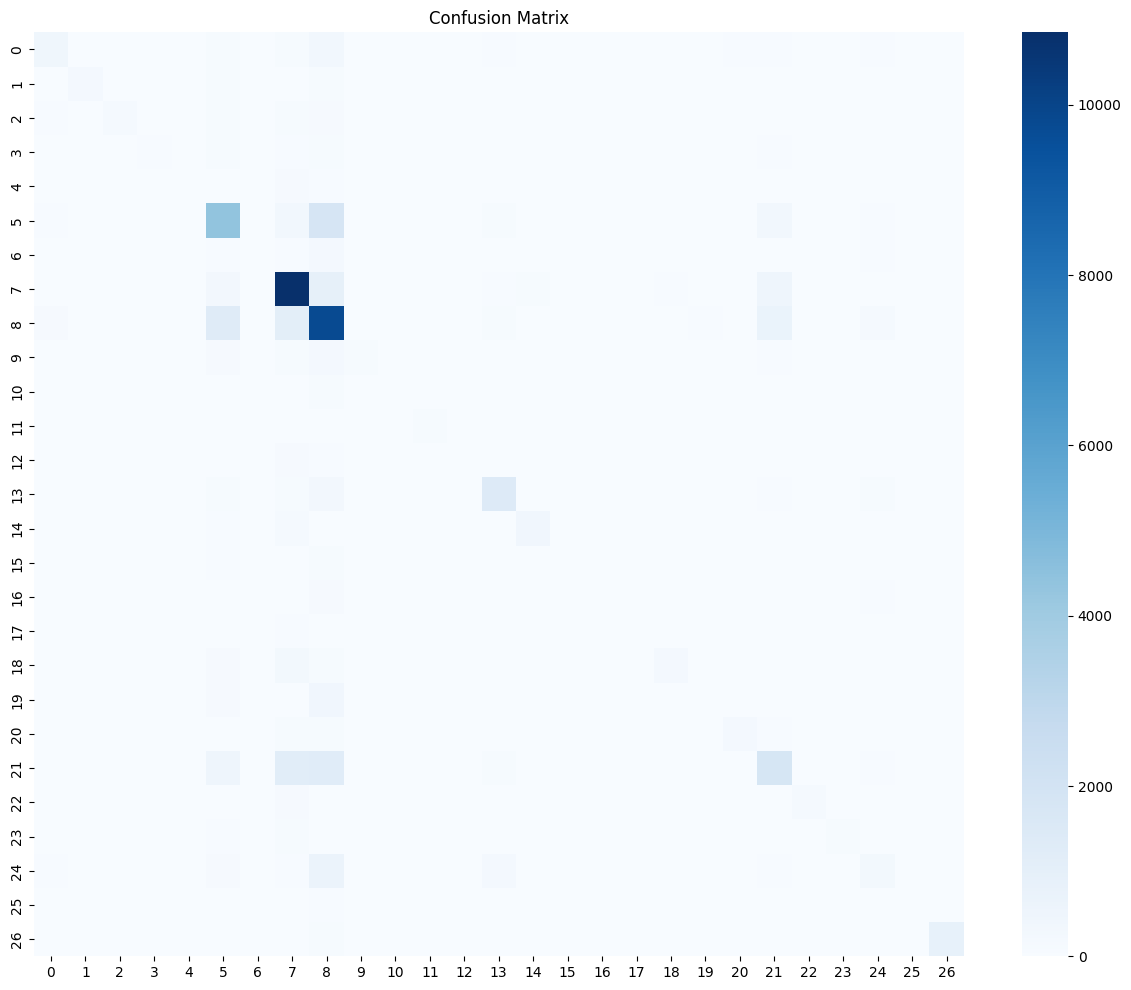

In [21]:
cm = confusion_matrix(actual, predictions)

plt.figure(figsize=(15,12))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [22]:
plot = """
A young superhero discovers his powers and
must save the world from an alien invasion.
"""

genre = model.predict([plot])

print("Predicted Genre:", genre[0])

Predicted Genre: sci-fi


In [23]:
import joblib

joblib.dump(
    model,
    "movie_genre_model.pkl"
)

print("Model Saved")

Model Saved
